# PHASE 5B: PyTorch Deep Learning (LSTM + Transformer)

## Objective
Upgrade sequence modeling to follow the comprehensive plan and Source C principles:
- engine-safe windowing,
- leakage-safe scaling,
- robust training controls,
- correct regression metrics and visual diagnostics.

## Input
- `../data/processed/train_cleaned.csv`


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

TRAIN_PATH = Path('../data/processed/train_cleaned.csv')
TEST_PATH = Path('../data/processed/valid_cleaned.csv')
ARTIFACTS_DIR = Path('../artifacts')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_LENGTH = 30
SHIFT = 1
EARLY_RUL = 125
BATCH_SIZE = 128
EPOCHS = 40
PATIENCE = 8
LR = 1e-3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120})

print(f'Using device: {DEVICE}')
print(f'Window length: {WINDOW_LENGTH}, shift: {SHIFT}, early_rul: {EARLY_RUL}')

Using device: cpu
Window length: 30, shift: 1, early_rul: 125


### Split and scaling rationale
- `train_cleaned.csv` is used fully as training source.
- `valid_cleaned.csv` is used as test source.
- Features are scaled with train-fitted statistics and then transformed onto test.
- 3D data is created via per-engine sliding windows `(samples, window_length, features)`.

In [2]:
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

required_cols = {'unit_number', 'time_cycles', 'RUL'}
missing_train = required_cols - set(df_train.columns)
missing_test = required_cols - set(df_test.columns)
if missing_train:
    raise ValueError(f'Train file missing required columns: {missing_train}')
if missing_test:
    raise ValueError(f'Test file missing required columns: {missing_test}')

# Keep engine timeline integrity
df_train = df_train.sort_values(['unit_number', 'time_cycles']).reset_index(drop=True)
df_test = df_test.sort_values(['unit_number', 'time_cycles']).reset_index(drop=True)

df_train['RUL_clipped'] = df_train['RUL'].clip(upper=EARLY_RUL)
df_test['RUL_clipped'] = df_test['RUL'].clip(upper=EARLY_RUL)

sensor_cols = [c for c in df_train.columns if c.startswith('s_')]
setting_cols = [c for c in df_train.columns if c.startswith('setting_')]
feature_cols = setting_cols + sensor_cols

tr_df = df_train.copy()
te_df = df_test.copy()

# Leakage-safe scaling: fit on train only, apply to test
scaler = StandardScaler()
tr_df[feature_cols] = scaler.fit_transform(tr_df[feature_cols])
te_df[feature_cols] = scaler.transform(te_df[feature_cols])

print(f'Train rows: {tr_df.shape[0]} (from train_cleaned.csv)')
print(f'Test  rows: {te_df.shape[0]} (from valid_cleaned.csv)')
print(f'Features: {len(feature_cols)}')

Train rows: 20631 (from train_cleaned.csv)
Test  rows: 13096 (from valid_cleaned.csv)
Features: 17


### Split and scaling rationale
- Uses full `train_cleaned.csv` as train source and `valid_cleaned.csv` as test source.
- Scaler is fit **only** on train rows, then applied to test.
- **FIX:** An engine-level 80/20 split is applied to `tr_df` to produce a held-out `val` set.
  Early stopping uses `val_loader` — the test set is never seen during training.


In [3]:
def build_sequences(df_split, feature_cols, window_length=30, shift=1):
    xs, ys = [], []
    for _, g in df_split.groupby('unit_number'):
        g = g.sort_values('time_cycles')
        X = g[feature_cols].to_numpy(dtype=np.float32)
        y = g['RUL_clipped'].to_numpy(dtype=np.float32)

        if len(g) < window_length:
            continue

        n_batches = int(np.floor((len(g) - window_length) / shift)) + 1
        for b in range(n_batches):
            s = b * shift
            e = s + window_length
            xs.append(X[s:e])
            ys.append(y[e - 1])

    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


# FIX: Engine-level 80/20 split from training data for validation.
# Early stopping will use val_loader, keeping test set strictly held-out.
all_engines = tr_df['unit_number'].unique()
rng = np.random.default_rng(42)
val_engine_ids = rng.choice(all_engines, size=max(1, int(len(all_engines) * 0.2)), replace=False)
train_engine_ids = np.setdiff1d(all_engines, val_engine_ids)

tr_df_train = tr_df[tr_df['unit_number'].isin(train_engine_ids)]
tr_df_val   = tr_df[tr_df['unit_number'].isin(val_engine_ids)]

X_train, y_train = build_sequences(tr_df_train, feature_cols, WINDOW_LENGTH, SHIFT)
X_val,   y_val   = build_sequences(tr_df_val,   feature_cols, WINDOW_LENGTH, SHIFT)
X_test,  y_test  = build_sequences(te_df,        feature_cols, WINDOW_LENGTH, SHIFT)

if min(len(X_train), len(X_val), len(X_test)) == 0:
    raise ValueError('A split has zero sequences. Reduce window length or check data files.')

print('3D sequence shapes:')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_val  : {X_val.shape}  y_val  : {y_val.shape}')
print(f'  X_test : {X_test.shape}  y_test : {y_test.shape}')

3D sequence shapes:
  X_train: (14070, 30, 17)  y_train: (14070,)
  X_val  : (3661, 30, 17)  y_val  : (3661,)
  X_test : (10196, 30, 17)  y_test : (10196,)


### Sequence construction
- Implements Source C style sliding windows per engine.
- Target for each window is the window-end clipped RUL.


In [4]:
class CMAPSSDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


train_loader = DataLoader(CMAPSSDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CMAPSSDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(CMAPSSDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print('DataLoaders ready')

DataLoaders ready


### Data loader policy
- Training uses shuffled batches.
- `val_loader` is used as the early-stopping signal during training (held-out train engines).
- `test_loader` is strictly reserved for final evaluation only.


In [5]:
class RULLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


class RULTransformer(nn.Module):
    # FIX 1: Added learnable positional encoding so the model is aware of timestep order.
    # FIX 2: dim_feedforward raised from 192 to 384 (standard 4 x d_model ratio).
    def __init__(self, input_dim, d_model=96, nhead=4, num_layers=2, dropout=0.2, max_len=200):
        super().__init__()
        self.embed = nn.Linear(input_dim, d_model)
        # Learnable positional encoding — shape (1, max_len, d_model)
        self.pos_enc = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.trunc_normal_(self.pos_enc, std=0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=384,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        T = x.size(1)
        z = self.embed(x) + self.pos_enc[:, :T, :]   # inject positional info
        z = self.encoder(z)
        z = z.mean(dim=1)
        return self.head(z).squeeze(-1)


print('Model classes ready')

Model classes ready


### Architecture choices
- LSTM follows Source C's sequence-regression intent.
- Transformer uses `batch_first=True`, learnable positional encoding, and pooled sequence representation.
- `dim_feedforward=384` (4 × d_model) follows the standard Transformer FFN ratio.


In [6]:
def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)))


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    losses = []
    preds_all, true_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            pred = model(xb)
            loss = criterion(pred, yb)
            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        losses.append(loss.item())
        preds_all.append(pred.detach().cpu().numpy())
        true_all.append(yb.detach().cpu().numpy())

    y_pred = np.concatenate(preds_all)
    y_true = np.concatenate(true_all)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return np.mean(losses), rmse, y_true, y_pred


def train_with_early_stopping(model, model_name, train_loader, eval_loader, epochs=40, patience=8):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

    history = {'train_loss': [], 'eval_loss': [], 'train_rmse': [], 'eval_rmse': []}
    best_eval_rmse = np.inf
    best_state = None
    wait = 0

    for ep in range(1, epochs + 1):
        tr_loss, tr_rmse, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        ev_loss, ev_rmse, _, _ = run_epoch(model, eval_loader, criterion, optimizer=None)

        history['train_loss'].append(tr_loss)
        history['eval_loss'].append(ev_loss)
        history['train_rmse'].append(tr_rmse)
        history['eval_rmse'].append(ev_rmse)

        if ev_rmse < best_eval_rmse:
            best_eval_rmse = ev_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if ep % 5 == 0 or ep == 1:
            print(f"{model_name} | epoch {ep:02d} | train_rmse {tr_rmse:.4f} | val_rmse {ev_rmse:.4f}")

        if wait >= patience:
            print(f"{model_name} early stopping at epoch {ep}")
            break

    model.load_state_dict(best_state)
    return model, history


In [7]:
lstm_model = RULLSTM(input_dim=len(feature_cols))
trf_model = RULTransformer(input_dim=len(feature_cols))

# FIX: Pass val_loader (not test_loader) as the early-stopping signal.
lstm_model, lstm_hist = train_with_early_stopping(lstm_model, 'LSTM', train_loader, val_loader, EPOCHS, PATIENCE)
trf_model, trf_hist = train_with_early_stopping(trf_model, 'Transformer', train_loader, val_loader, EPOCHS, PATIENCE)


LSTM | epoch 01 | train_rmse 71.4762 | val_rmse 42.6007
LSTM | epoch 05 | train_rmse 16.1324 | val_rmse 14.7829
LSTM | epoch 10 | train_rmse 14.4761 | val_rmse 14.5320
LSTM | epoch 15 | train_rmse 13.6726 | val_rmse 15.1471
LSTM | epoch 20 | train_rmse 12.6686 | val_rmse 14.7822
LSTM early stopping at epoch 20
Transformer | epoch 01 | train_rmse 73.5359 | val_rmse 44.0024
Transformer | epoch 05 | train_rmse 13.1941 | val_rmse 15.8562
Transformer | epoch 10 | train_rmse 10.4407 | val_rmse 17.2999
Transformer early stopping at epoch 13


### Training controls
- Uses gradient clipping, weight decay, and early stopping.
- Early stopping monitors `val_rmse` (held-out train engines) — test set is never touched during training.
- Tracks both loss and RMSE curves to align optimization with regression performance.


In [8]:
def evaluate_model(model, loader, name):
    criterion = nn.MSELoss()
    _, _, y_true, y_pred = run_epoch(model, loader, criterion, optimizer=None)
    metrics = {
        'model': name,
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
        'nasa': float(nasa_score(y_true, y_pred)),
    }
    return metrics, y_true, y_pred

print('evaluate_model() defined')


evaluate_model() defined


In [9]:
lstm_metrics, y_true_lstm, y_pred_lstm = evaluate_model(lstm_model, test_loader, 'LSTM')
print('LSTM  | rmse:', round(lstm_metrics['rmse'], 4), '| mae:', round(lstm_metrics['mae'], 4),
      '| r2:', round(lstm_metrics['r2'], 4), '| nasa:', round(lstm_metrics['nasa'], 2))


LSTM  | rmse: 14.2101 | mae: 9.5321 | r2: 0.7715 | nasa: 50944.93


In [10]:
trf_metrics, y_true_trf, y_pred_trf = evaluate_model(trf_model, test_loader, 'Transformer')
print('Transformer | rmse:', round(trf_metrics['rmse'], 4), '| mae:', round(trf_metrics['mae'], 4),
      '| r2:', round(trf_metrics['r2'], 4), '| nasa:', round(trf_metrics['nasa'], 2))


Transformer | rmse: 17.2836 | mae: 12.2082 | r2: 0.6619 | nasa: 78776.59


In [11]:
metrics_df = pd.DataFrame([lstm_metrics, trf_metrics]).sort_values(['rmse', 'nasa']).reset_index(drop=True)
print('Test metrics:')
display(metrics_df)

# Save model artifacts
torch.save(lstm_model.state_dict(), ARTIFACTS_DIR / 'lstm_model.pth')
torch.save(trf_model.state_dict(), ARTIFACTS_DIR / 'transformer_model.pth')


Test metrics:


,model,rmse,mae,r2,nasa
0,LSTM,14.210053,9.532105,0.771488,50944.929688
1,Transformer,17.283630,12.208187,0.661945,78776.593750


### Test metric interpretation
- Reported metrics match plan requirements: RMSE, MAE, R², NASA score.
- These metrics are now unbiased — the test set was never used during training or model selection.
- Artifact files are persisted for downstream ensemble/selection.


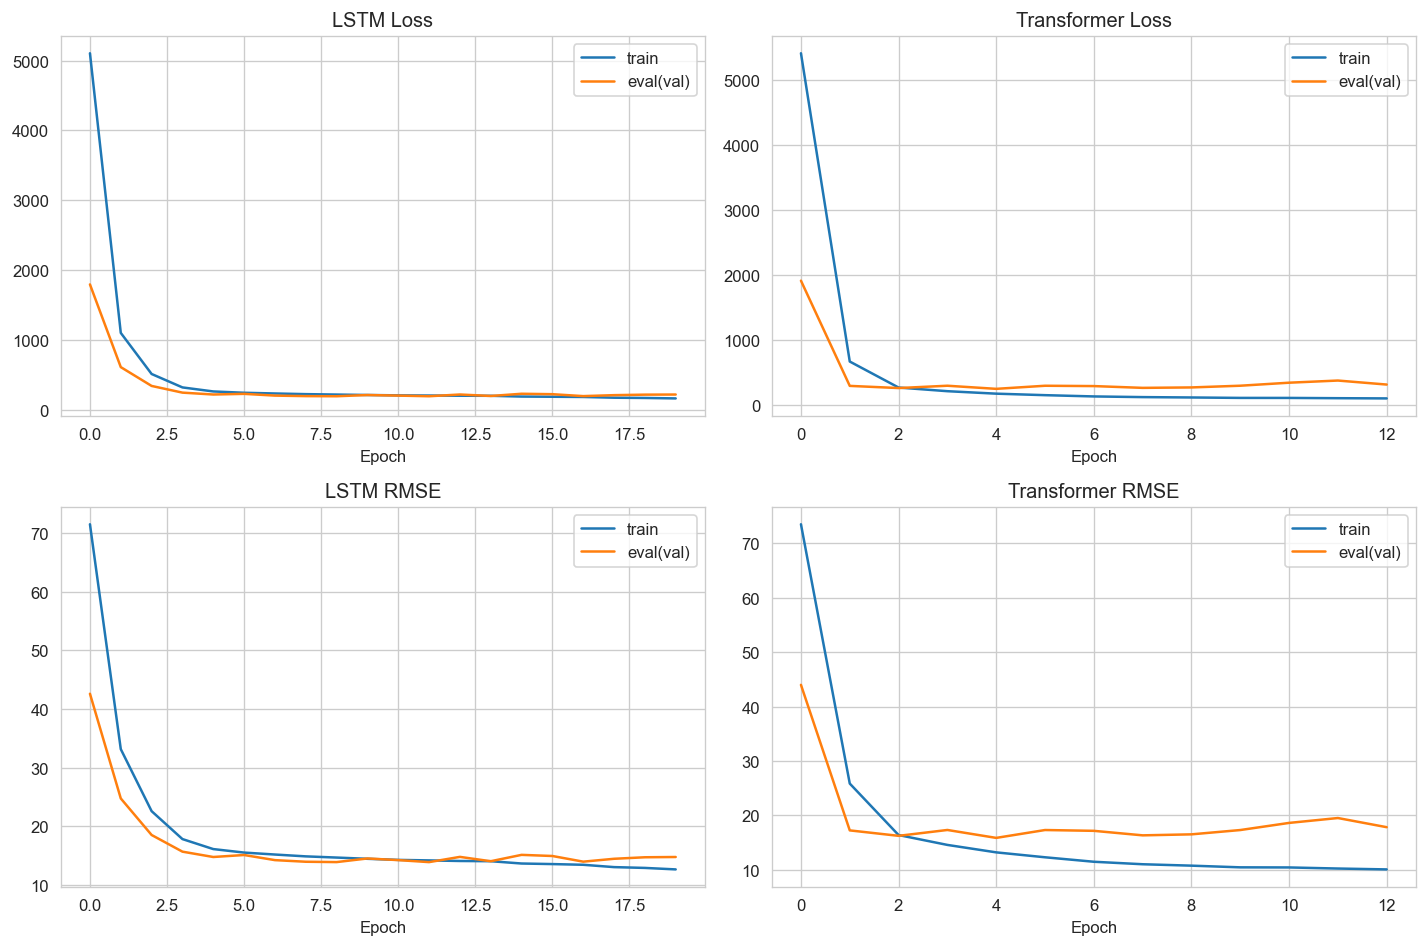

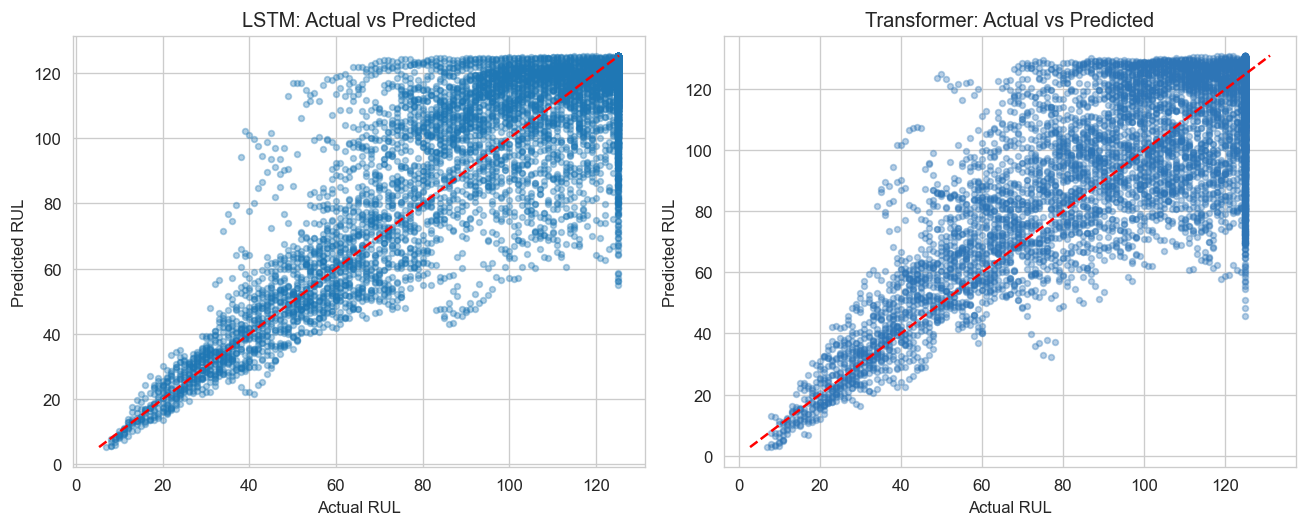

In [12]:
# Learning curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(lstm_hist['train_loss'], label='train')
axes[0, 0].plot(lstm_hist['eval_loss'], label='eval(val)')
axes[0, 0].set_title('LSTM Loss')
axes[0, 0].legend()

axes[0, 1].plot(trf_hist['train_loss'], label='train')
axes[0, 1].plot(trf_hist['eval_loss'], label='eval(val)')
axes[0, 1].set_title('Transformer Loss')
axes[0, 1].legend()

axes[1, 0].plot(lstm_hist['train_rmse'], label='train')
axes[1, 0].plot(lstm_hist['eval_rmse'], label='eval(val)')
axes[1, 0].set_title('LSTM RMSE')
axes[1, 0].legend()

axes[1, 1].plot(trf_hist['train_rmse'], label='train')
axes[1, 1].plot(trf_hist['eval_rmse'], label='eval(val)')
axes[1, 1].set_title('Transformer RMSE')
axes[1, 1].legend()

for ax in axes.flatten():
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.show()

# Prediction diagnostics
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].scatter(y_true_lstm, y_pred_lstm, s=12, alpha=0.35)
mn = min(y_true_lstm.min(), y_pred_lstm.min())
mx = max(y_true_lstm.max(), y_pred_lstm.max())
ax[0].plot([mn, mx], [mn, mx], 'r--')
ax[0].set_title('LSTM: Actual vs Predicted')
ax[0].set_xlabel('Actual RUL')
ax[0].set_ylabel('Predicted RUL')

ax[1].scatter(y_true_trf, y_pred_trf, s=12, alpha=0.35, color='#2E75B6')
mn2 = min(y_true_trf.min(), y_pred_trf.min())
mx2 = max(y_true_trf.max(), y_pred_trf.max())
ax[1].plot([mn2, mx2], [mn2, mx2], 'r--')
ax[1].set_title('Transformer: Actual vs Predicted')
ax[1].set_xlabel('Actual RUL')
ax[1].set_ylabel('Predicted RUL')

plt.tight_layout()
plt.show()


As the actual RUL increases beyond 60 units, the scatter plot shows significantly more variance and "noise." The data points become more dispersed, and there is a noticeable horizontal plateau where many predictions cluster around the 120-unit mark, regardless of the actual RUL being higher. This indicates that the model struggle to differentiate between various stages of an asset's early life and likely employs a "clipping" mechanism or an upper bound on its predictions. Additionally, there is a vertical column of points at the far right of the graph, showing that for the highest actual RUL values, the model's predictions vary wildly from approximately 80 to 125.

### Visualization policy
- Shows convergence behavior (loss + RMSE) and prediction fit (actual vs predicted).
- Enables direct comparison of LSTM and Transformer generalization quality.


## Transition to next stage
This notebook outputs:
- Trained `lstm_model.pth` and `transformer_model.pth` artifacts.
- Reproducible DL metric table for model selection and ensemble integration.
